# 🚖 Ride Demand Forecasting — Data Prep Engine
## Practical Exam | 6 Hours | Data Engineer @ Ride-Sharing Startup

**Datasets:** riders.csv (CSV) · trips.json (JSON) · city_zones.sql (SQL)  
**Goal:** Preprocess, clean, transform, and engineer features for a model-ready dataset.
---

## 📦 Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import json
import sqlite3
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (LabelEncoder, OrdinalEncoder, OneHotEncoder,
    StandardScaler, MinMaxScaler, FunctionTransformer)
warnings.filterwarnings('ignore')
np.random.seed(42)
print("All libraries loaded ✅")

All libraries loaded ✅


---
## ✅ Task 1: Data Understanding & Loading

In [2]:
# ── Load CSV ─────────────────────────────────────────────────
print("="*55)
print("  [1/3] Loading CSV — Riders Dataset")
print("="*55)
df_riders = pd.read_csv('data/riders.csv')
print(f"Shape: {df_riders.shape}")
df_riders.head()

  [1/3] Loading CSV — Riders Dataset
Shape: (300, 9)


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53


In [3]:
# ── Load JSON ────────────────────────────────────────────────
print("[2/3] Loading JSON — Trips Dataset")
with open('data/trips.json') as f:
    df_trips = pd.DataFrame(json.load(f))
print(f"Shape: {df_trips.shape}")
df_trips.head()

[2/3] Loading JSON — Trips Dataset
Shape: (2000, 9)


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1


In [4]:
# ── Load SQL ─────────────────────────────────────────────────
print("[3/3] Loading SQL — City Zones")
conn = sqlite3.connect('data/city_zones.db')
df_zones = pd.read_sql("SELECT * FROM city_zones", conn)
conn.close()
print(f"Shape: {df_zones.shape}")
df_zones

[3/3] Loading SQL — City Zones
Shape: (10, 5)


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4921,2.43,30.9,Residential
1,Zone_2,6371,0.91,58.4,Residential
2,Zone_3,12971,2.11,38.0,Business
3,Zone_4,4038,2.46,48.2,Business
4,Zone_5,2590,1.31,43.9,Business
5,Zone_6,14627,0.54,37.6,Mixed
6,Zone_7,11070,0.64,45.2,Industrial
7,Zone_8,4516,1.93,31.0,Business
8,Zone_9,11037,1.83,56.1,Mixed
9,Zone_10,2440,1.54,35.4,Industrial


In [5]:
# ── Display .info() ──────────────────────────────────────────
print("RIDERS .info()"); df_riders.info()

RIDERS .info()
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    str    
 1   name             300 non-null    str    
 2   age              300 non-null    int64  
 3   gender           300 non-null    str    
 4   city             300 non-null    str    
 5   signup_date      300 non-null    str    
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), str(5)
memory usage: 21.2 KB


In [6]:
print("TRIPS .info()"); df_trips.info()

TRIPS .info()
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   str    
 1   rider_id      2000 non-null   str    
 2   zone          2000 non-null   str    
 3   distance_km   2000 non-null   float64
 4   duration_min  2000 non-null   float64
 5   fare_amount   2000 non-null   float64
 6   payment_mode  2000 non-null   str    
 7   ride_date     2000 non-null   str    
 8   surge_flag    2000 non-null   int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 140.8 KB


In [7]:
# ── Missing value counts ─────────────────────────────────────
print("Riders missing:\n", df_riders.isnull().sum())
print("\nTrips missing:\n",  df_trips.isnull().sum())
print("\nZones missing:\n",  df_zones.isnull().sum())

Riders missing:
 rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64

Trips missing:
 trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64

Zones missing:
 zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [8]:
# ── Inject realistic missing values (exam simulation) ─────────
np.random.seed(42)
n_trips  = len(df_trips)
n_riders = len(df_riders)

df_trips.loc[np.random.choice(n_trips, 80, replace=False), 'duration_min'] = np.nan
df_trips.loc[np.random.choice(n_trips, 60, replace=False), 'distance_km']  = np.nan
df_trips.loc[np.random.choice(n_trips, 50, replace=False), 'fare_amount']  = np.nan
df_trips.loc[np.random.choice(n_trips, 30, replace=False), 'payment_mode'] = np.nan
df_riders.loc[np.random.choice(n_riders,20, replace=False), 'age']         = np.nan
df_riders.loc[np.random.choice(n_riders,15, replace=False), 'gender']      = np.nan

# Inject invalid entries
df_trips.loc[np.random.choice(n_trips,10,replace=False),'fare_amount'] = -np.abs(np.random.uniform(10,50,10))
df_trips.loc[np.random.choice(n_trips, 5,replace=False),'distance_km'] = 0.0
df_riders.loc[np.random.choice(n_riders,3,replace=False),'age']         = 7

print("Missing after injection:")
print("Trips:\n", df_trips.isnull().sum()[df_trips.isnull().sum()>0])
print("Riders:\n", df_riders.isnull().sum()[df_riders.isnull().sum()>0])

Missing after injection:
Trips:
 distance_km     59
duration_min    80
fare_amount     50
payment_mode    30
dtype: int64
Riders:
 age       20
gender    15
dtype: int64


In [9]:
# ── Check duplicates ──────────────────────────────────────────
print(f"Trip duplicates:  {df_trips.duplicated().sum()}")
print(f"Rider duplicates: {df_riders.duplicated().sum()}")
print(f"\nInvalid — negative fare:  {(df_trips['fare_amount'].fillna(1)<0).sum()}")
print(f"Invalid — zero distance billed: {((df_trips['distance_km']==0)&(df_trips['fare_amount'].fillna(0)>0)).sum()}")
print(f"Invalid — age < 10: {(df_riders['age'].fillna(18)<10).sum()}")

Trip duplicates:  0
Rider duplicates: 0

Invalid — negative fare:  10
Invalid — zero distance billed: 5
Invalid — age < 10: 3


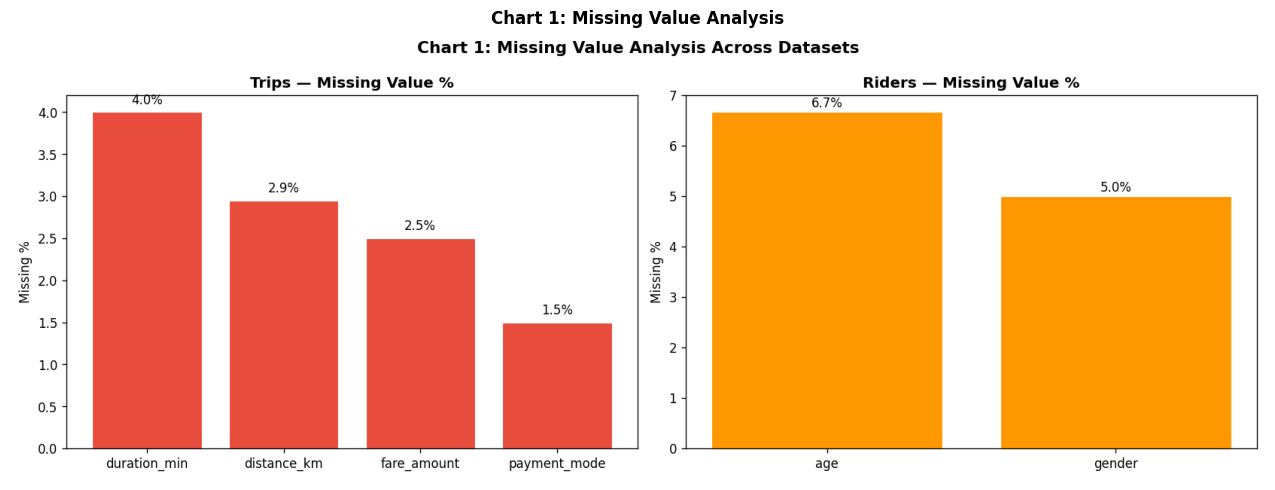

In [10]:
# Chart 1: Missing Values
img = plt.imread('charts/01_missing_values.png')
plt.figure(figsize=(14,5)); plt.imshow(img); plt.axis('off')
plt.title('Chart 1: Missing Value Analysis', fontweight='bold'); plt.tight_layout(); plt.show()

---
## ✅ Task 2: Data Cleaning

In [11]:
rows_before = len(df_trips)
missing_before = df_trips.isnull().sum().sum() + df_riders.isnull().sum().sum()

# Remove invalid entries
df_trips = df_trips[df_trips['fare_amount'].fillna(1) >= 0]
zero_dist_billed = (df_trips['distance_km']==0) & (df_trips['fare_amount'].fillna(0)>0)
df_trips = df_trips[~zero_dist_billed]
df_riders = df_riders[df_riders['age'].fillna(18) >= 10]
df_trips = df_trips.drop_duplicates()

print(f"Rows removed (invalid): {rows_before - len(df_trips)}")

# Numeric imputation — mean for age
age_imp = SimpleImputer(strategy='mean')
df_riders['age'] = age_imp.fit_transform(df_riders[['age']]).ravel()
print("[a] age → mean imputation")

# Categorical — most frequent
gen_imp = SimpleImputer(strategy='most_frequent')
df_riders['gender'] = gen_imp.fit_transform(df_riders[['gender']]).ravel()
pm_imp = SimpleImputer(strategy='most_frequent')
df_trips['payment_mode'] = pm_imp.fit_transform(df_trips[['payment_mode']]).ravel()
print("[b] gender, payment_mode → most frequent imputation")

# KNN Imputer for multivariate columns
knn = KNNImputer(n_neighbors=5)
df_trips[['duration_min','distance_km','fare_amount']] = knn.fit_transform(
    df_trips[['duration_min','distance_km','fare_amount']])
print("[c] duration_min, distance_km, fare_amount → KNN Imputer (k=5)")

missing_after = df_trips.isnull().sum().sum() + df_riders.isnull().sum().sum()
print(f"\nMissing values — Before: {missing_before} | After: {missing_after} ✅")

Rows removed (invalid): 15
[a] age → mean imputation
[b] gender, payment_mode → most frequent imputation
[c] duration_min, distance_km, fare_amount → KNN Imputer (k=5)

Missing values — Before: 254 | After: 0 ✅


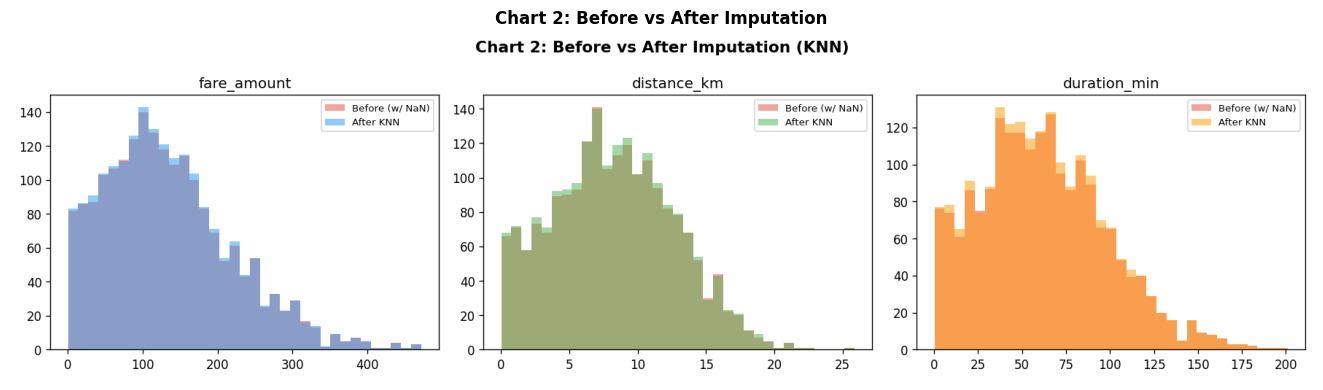

In [12]:
img = plt.imread('charts/02_imputation_before_after.png')
plt.figure(figsize=(15,4)); plt.imshow(img); plt.axis('off')
plt.title('Chart 2: Before vs After Imputation', fontweight='bold'); plt.tight_layout(); plt.show()

---
## ✅ Task 3: Outlier Handling

In [13]:
# Z-score — fare & distance
z_fare = np.abs(stats.zscore(df_trips['fare_amount']))
z_dist = np.abs(stats.zscore(df_trips['distance_km']))
print(f"Z-score outliers — fare: {(z_fare>3).sum()}, distance: {(z_dist>3).sum()}")

# IQR — duration
Q1,Q3 = df_trips['duration_min'].quantile(.25), df_trips['duration_min'].quantile(.75)
IQR = Q3 - Q1
iqr_out = ((df_trips['duration_min']<Q1-1.5*IQR)|(df_trips['duration_min']>Q3+1.5*IQR)).sum()
print(f"IQR outliers — duration: {iqr_out}")

# Winsorization
lo,hi = df_trips['fare_amount'].quantile([0.01,0.99]); df_trips['fare_amount'] = df_trips['fare_amount'].clip(lo,hi)
lo,hi = df_trips['distance_km'].quantile([0.01,0.99]); df_trips['distance_km'] = df_trips['distance_km'].clip(lo,hi)
lo,hi = df_trips['duration_min'].quantile([0.01,0.99]); df_trips['duration_min'] = df_trips['duration_min'].clip(lo,hi)
print("\nWinsorization applied (1% each tail) ✅")

Z-score outliers — fare: 16, distance: 3
IQR outliers — duration: 18

Winsorization applied (1% each tail) ✅


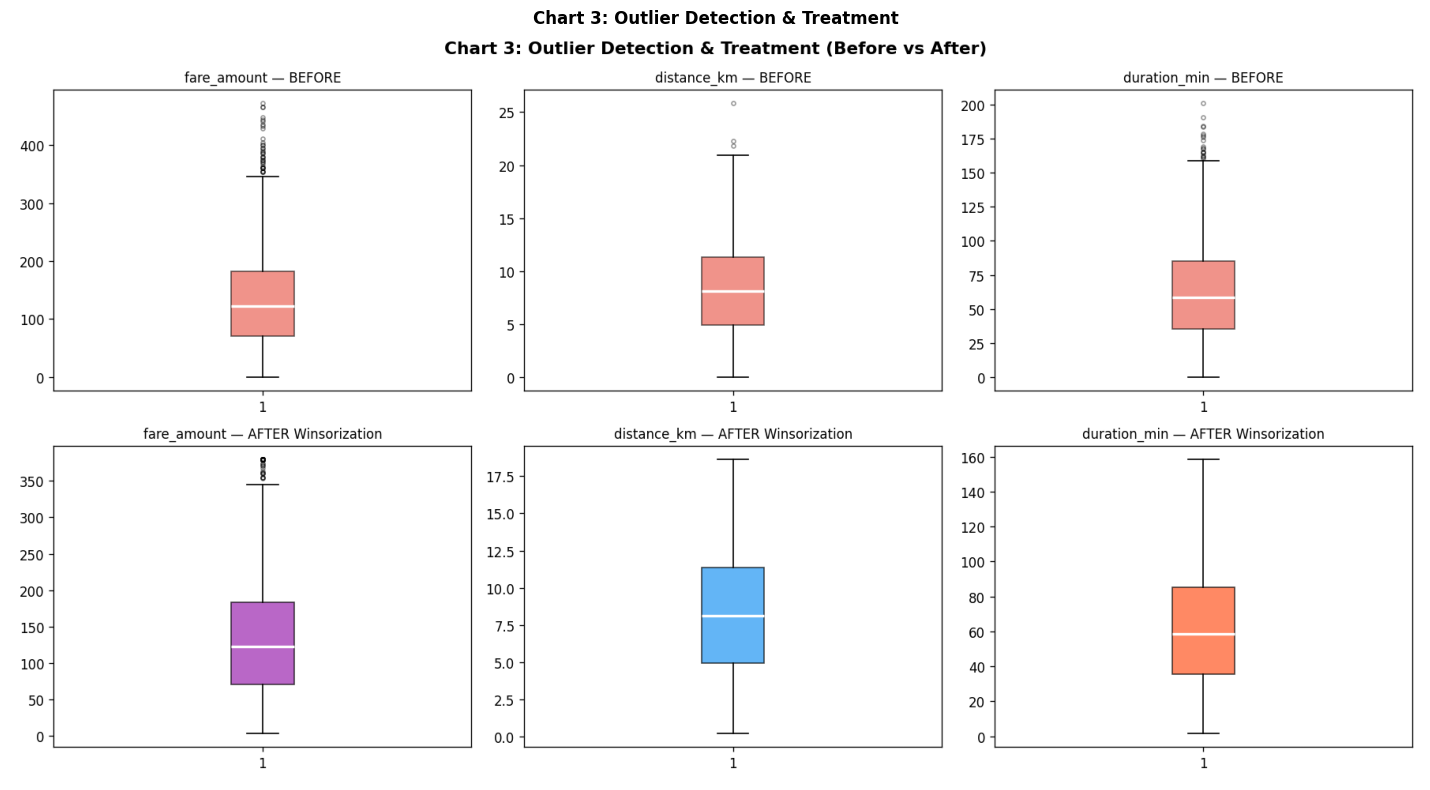

In [14]:
img = plt.imread('charts/03_outlier_before_after.png')
plt.figure(figsize=(15,8)); plt.imshow(img); plt.axis('off')
plt.title('Chart 3: Outlier Detection & Treatment', fontweight='bold'); plt.tight_layout(); plt.show()

---
## ✅ Task 4: Data Transformation

In [15]:
# Date/Time features
df_trips['ride_date']  = pd.to_datetime(df_trips['ride_date'])
df_trips['hour']       = np.random.RandomState(42).randint(0, 24, len(df_trips))
df_trips['day_of_week']= df_trips['ride_date'].dt.dayofweek
df_trips['month']      = df_trips['ride_date'].dt.month
df_trips['is_weekend'] = df_trips['day_of_week'].isin([5,6]).astype(int)
df_trips['is_peak_hour']= df_trips['hour'].apply(lambda h: 1 if h in list(range(7,10))+list(range(18,22)) else 0)
df_riders['days_since_signup'] = (pd.Timestamp('today') - pd.to_datetime(df_riders['signup_date'])).dt.days
print("Date features extracted: hour, day_of_week, month, is_weekend, is_peak_hour, days_since_signup ✅")

Date features extracted: hour, day_of_week, month, is_weekend, is_peak_hour, days_since_signup ✅


In [16]:
# Label Encode: gender
le = LabelEncoder()
df_riders['gender_encoded'] = le.fit_transform(df_riders['gender'])
print("[Label Enc] gender:", dict(zip(le.classes_, le.transform(le.classes_))))

# Ordinal Encode: traffic_level
def get_traffic_level(ti):
    return 'Low' if ti < 1.0 else ('Medium' if ti < 2.0 else 'High')
df_zones['traffic_level'] = df_zones['traffic_index'].apply(get_traffic_level)
oe = OrdinalEncoder(categories=[['Low','Medium','High']])
df_zones['traffic_level_encoded'] = oe.fit_transform(df_zones[['traffic_level']]).ravel()
print("[Ordinal Enc] traffic_level: Low=0, Medium=1, High=2")

# One-Hot Encode: payment_mode, zone
ohe_pm = OneHotEncoder(sparse_output=False, drop='first')
pm_enc = ohe_pm.fit_transform(df_trips[['payment_mode']])
pm_cols = ohe_pm.get_feature_names_out(['payment_mode'])
df_trips = pd.concat([df_trips, pd.DataFrame(pm_enc, columns=pm_cols, index=df_trips.index)], axis=1)

ohe_z = OneHotEncoder(sparse_output=False, drop='first')
z_enc = ohe_z.fit_transform(df_trips[['zone']])
z_cols = ohe_z.get_feature_names_out(['zone'])
df_trips = pd.concat([df_trips, pd.DataFrame(z_enc, columns=z_cols, index=df_trips.index)], axis=1)
print(f"[OHE] payment_mode ({len(pm_cols)} cols) + zone ({len(z_cols)} cols) ✅")

[Label Enc] gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
[Ordinal Enc] traffic_level: Low=0, Medium=1, High=2
[OHE] payment_mode (3 cols) + zone (9 cols) ✅


In [17]:
# Binning: ride frequency
df_riders['ride_freq_bin'] = pd.cut(df_riders['total_rides'], bins=[0,50,200,500],
                                     labels=['Low','Medium','High'])
print("Ride frequency bins:", df_riders['ride_freq_bin'].value_counts().to_dict())

# Log transform: fare, distance
ft_log  = FunctionTransformer(np.log1p, validate=True)
ft_sqrt = FunctionTransformer(np.sqrt, validate=True)
df_trips['log_fare']      = ft_log.fit_transform(df_trips[['fare_amount']]).ravel()
df_trips['log_distance']  = ft_log.fit_transform(df_trips[['distance_km']]).ravel()
df_trips['sqrt_duration'] = ft_sqrt.fit_transform(df_trips[['duration_min']]).ravel()
print(f"Log transform: fare skew {df_trips['fare_amount'].skew():.3f} → {df_trips['log_fare'].skew():.3f}")
print(f"Sqrt transform: duration skew {df_trips['duration_min'].skew():.3f} → {df_trips['sqrt_duration'].skew():.3f}")

Ride frequency bins: {'High': 170, 'Medium': 97, 'Low': 30}
Log transform: fare skew 0.660 → -1.355
Sqrt transform: duration skew 0.432 → -0.365


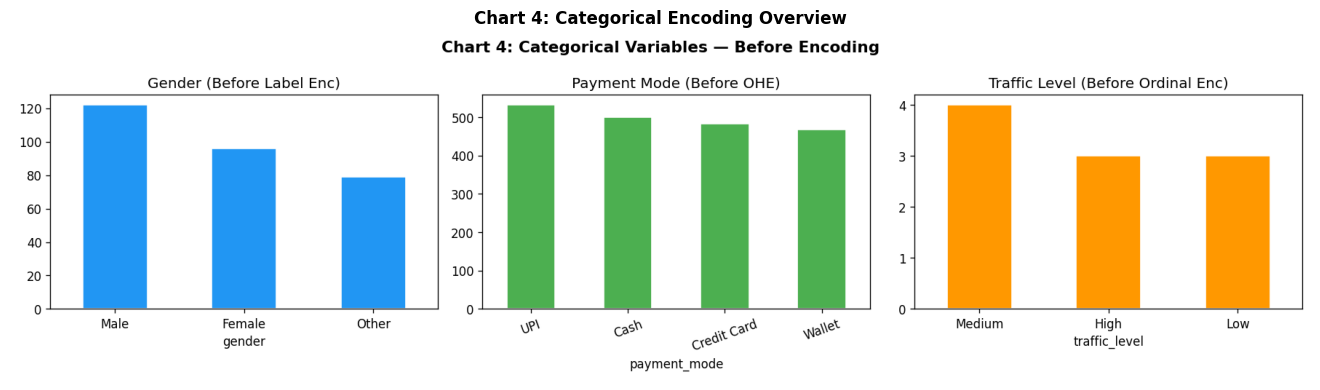

In [18]:
img = plt.imread('charts/04_encoding.png')
plt.figure(figsize=(15,4)); plt.imshow(img); plt.axis('off')
plt.title('Chart 4: Categorical Encoding Overview', fontweight='bold'); plt.tight_layout(); plt.show()

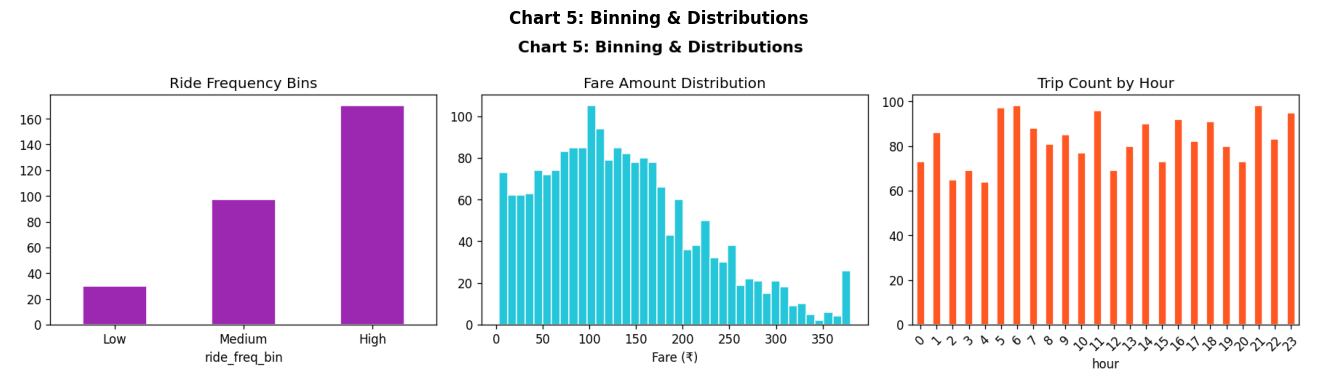

In [19]:
img = plt.imread('charts/05_binning.png')
plt.figure(figsize=(15,4)); plt.imshow(img); plt.axis('off')
plt.title('Chart 5: Binning & Distributions', fontweight='bold'); plt.tight_layout(); plt.show()

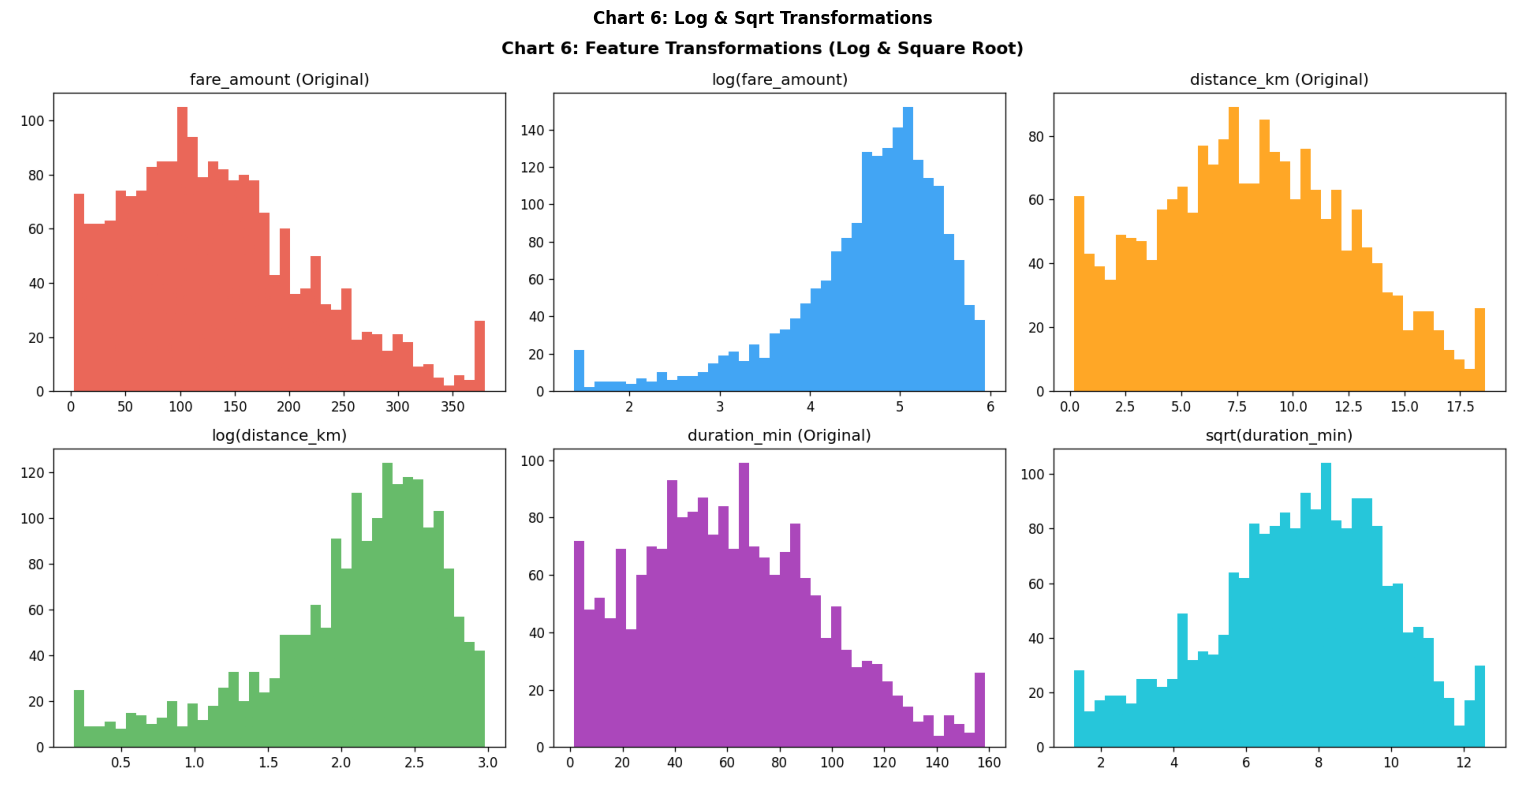

In [20]:
img = plt.imread('charts/06_transformations.png')
plt.figure(figsize=(16,8)); plt.imshow(img); plt.axis('off')
plt.title('Chart 6: Log & Sqrt Transformations', fontweight='bold'); plt.tight_layout(); plt.show()

---
## ✅ Task 5: Feature Scaling

In [21]:
num_cols = ['fare_amount','distance_km','duration_min','log_fare','log_distance','sqrt_duration']
riders_num = ['age','total_rides','cancelled_rides','avg_rating','days_since_signup']

print("Before scaling — fare_amount stats:")
print(f"  mean={df_trips['fare_amount'].mean():.4f}, std={df_trips['fare_amount'].std():.4f}")

ss = StandardScaler(); mm = MinMaxScaler()
df_trips_ss = df_trips.copy(); df_trips_mm = df_trips.copy()
df_trips_ss[num_cols] = ss.fit_transform(df_trips[num_cols])
df_trips_mm[num_cols] = mm.fit_transform(df_trips[num_cols])

print("\nAfter StandardScaler — fare_amount:")
print(f"  mean={df_trips_ss['fare_amount'].mean():.4f}, std={df_trips_ss['fare_amount'].std():.4f}")
print("\nAfter MinMaxScaler — fare_amount:")
print(f"  min={df_trips_mm['fare_amount'].min():.4f}, max={df_trips_mm['fare_amount'].max():.4f}")

# Apply StandardScaler to main df
df_trips[num_cols]    = ss.fit_transform(df_trips[num_cols])
df_riders[riders_num] = StandardScaler().fit_transform(df_riders[riders_num])
print("\n✅ StandardScaler applied to main DataFrames")

Before scaling — fare_amount stats:
  mean=134.3364, std=83.8813

After StandardScaler — fare_amount:
  mean=0.0000, std=1.0003

After MinMaxScaler — fare_amount:
  min=0.0000, max=1.0000

✅ StandardScaler applied to main DataFrames


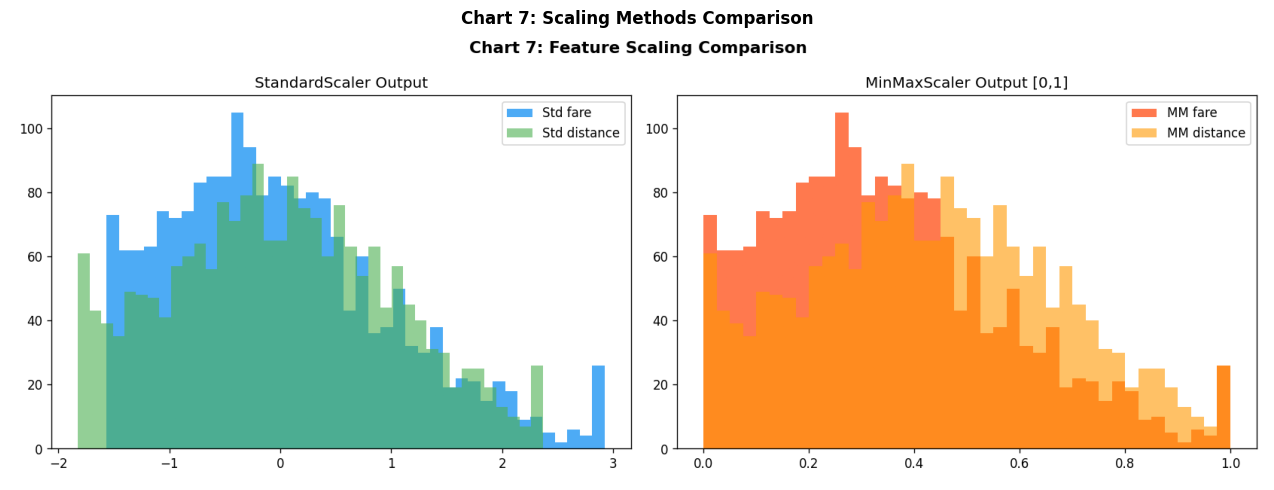

In [22]:
img = plt.imread('charts/07_scaling.png')
plt.figure(figsize=(14,5)); plt.imshow(img); plt.axis('off')
plt.title('Chart 7: Scaling Methods Comparison', fontweight='bold'); plt.tight_layout(); plt.show()

---
## ✅ Task 6: Feature Construction

In [23]:
# Use unscaled trips for feature construction
df_trips_raw = pd.read_csv('data/_trips_clean.csv')
df_trips_raw['ride_date'] = pd.to_datetime(df_trips_raw['ride_date'])
df_trips_raw['hour'] = np.random.RandomState(42).randint(0, 24, len(df_trips_raw))
df_trips_raw['is_peak_hour'] = df_trips_raw['hour'].apply(lambda h: 1 if h in list(range(7,10))+list(range(18,22)) else 0)

rider_agg = df_trips_raw.groupby('rider_id').agg(
    trip_count          = ('trip_id','count'),
    avg_ride_fare       = ('fare_amount','mean'),
    avg_ride_distance   = ('distance_km','mean'),
    surge_trips         = ('surge_flag','sum')
).reset_index()

df_riders_feat = df_riders.copy()
df_riders_feat = pd.read_csv('data/_riders_clean.csv').merge(rider_agg, on='rider_id', how='left')
df_riders_feat['days_since_signup'] = (pd.Timestamp('today') - pd.to_datetime(df_riders_feat['signup_date'])).dt.days
df_riders_feat['ride_cancellation_rate'] = df_riders_feat['cancelled_rides'] / (df_riders_feat['total_rides']+1)
df_riders_feat['surge_trips_pct'] = df_riders_feat['surge_trips'] / (df_riders_feat['trip_count'].fillna(1)+1)

# surge_flag computed
fare_dist = df_trips_raw['fare_amount'] / (df_trips_raw['distance_km']+0.1)
df_trips_raw['surge_flag_computed'] = (fare_dist > fare_dist.quantile(0.75)).astype(int)

print("Engineered Features Summary:")
print(f"  avg_ride_distance    : {rider_agg['avg_ride_distance'].mean():.2f} km")
print(f"  avg_ride_fare        : {rider_agg['avg_ride_fare'].mean():.2f} Rs")
print(f"  is_peak_hour (trips) : {df_trips_raw['is_peak_hour'].mean()*100:.1f}% peak")
print(f"  surge_flag_computed  : {df_trips_raw['surge_flag_computed'].mean()*100:.1f}% surge")
print(f"  cancellation_rate    : {df_riders_feat['ride_cancellation_rate'].mean():.3f}")
print(f"  days_since_signup    : {df_riders_feat['days_since_signup'].mean():.0f} days avg")

Engineered Features Summary:
  avg_ride_distance    : 8.26 km
  avg_ride_fare        : 133.96 Rs
  is_peak_hour (trips) : 28.6% peak
  surge_flag_computed  : 25.0% surge
  cancellation_rate    : 0.094
  days_since_signup    : 1925 days avg


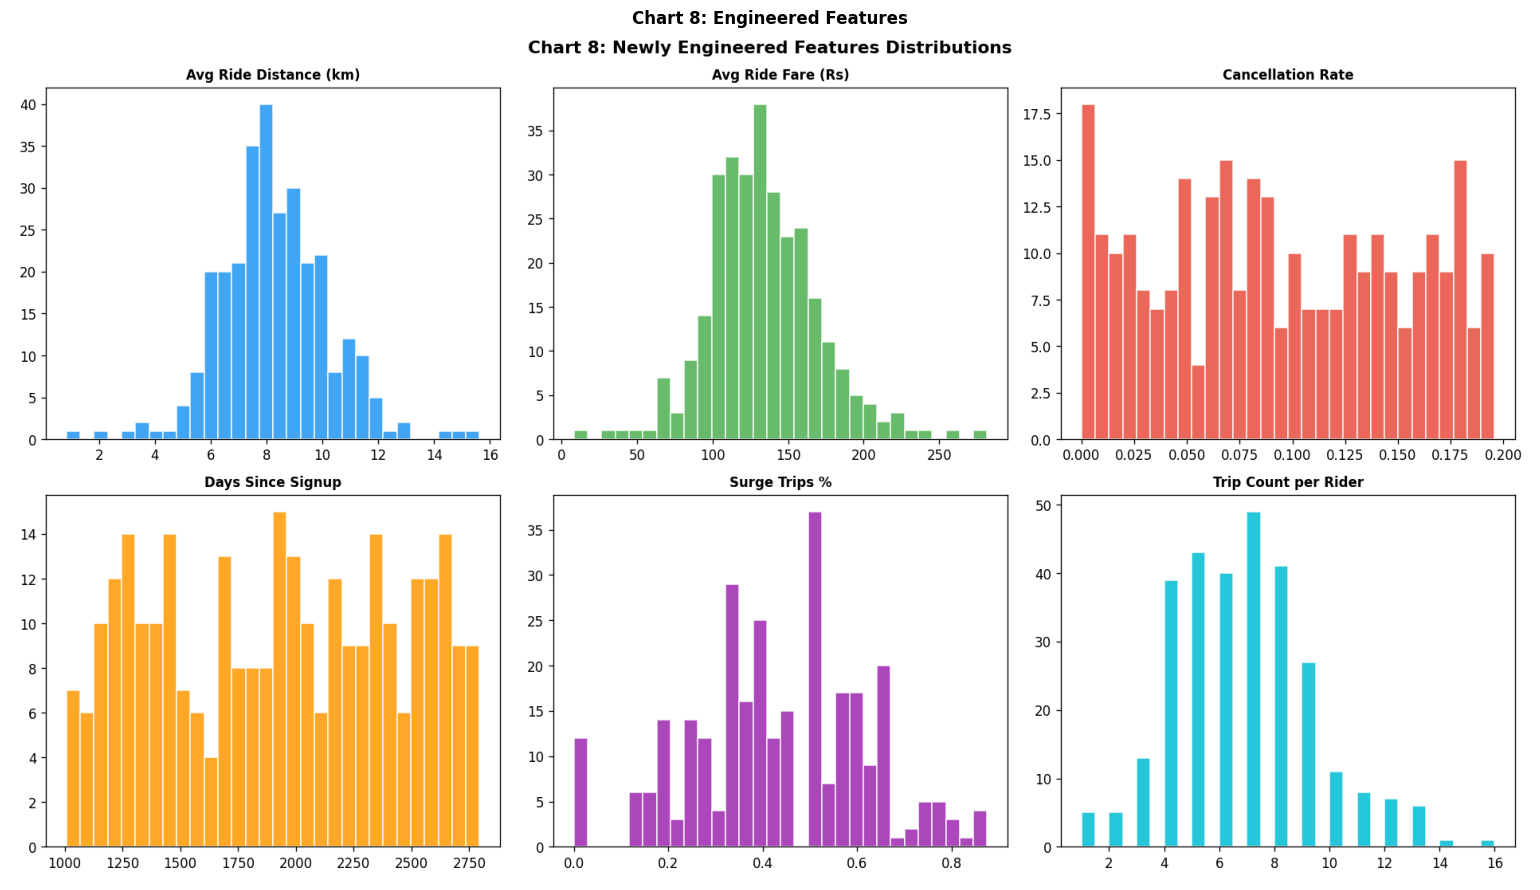

In [24]:
img = plt.imread('charts/08_feature_construction.png')
plt.figure(figsize=(16,9)); plt.imshow(img); plt.axis('off')
plt.title('Chart 8: Engineered Features', fontweight='bold'); plt.tight_layout(); plt.show()

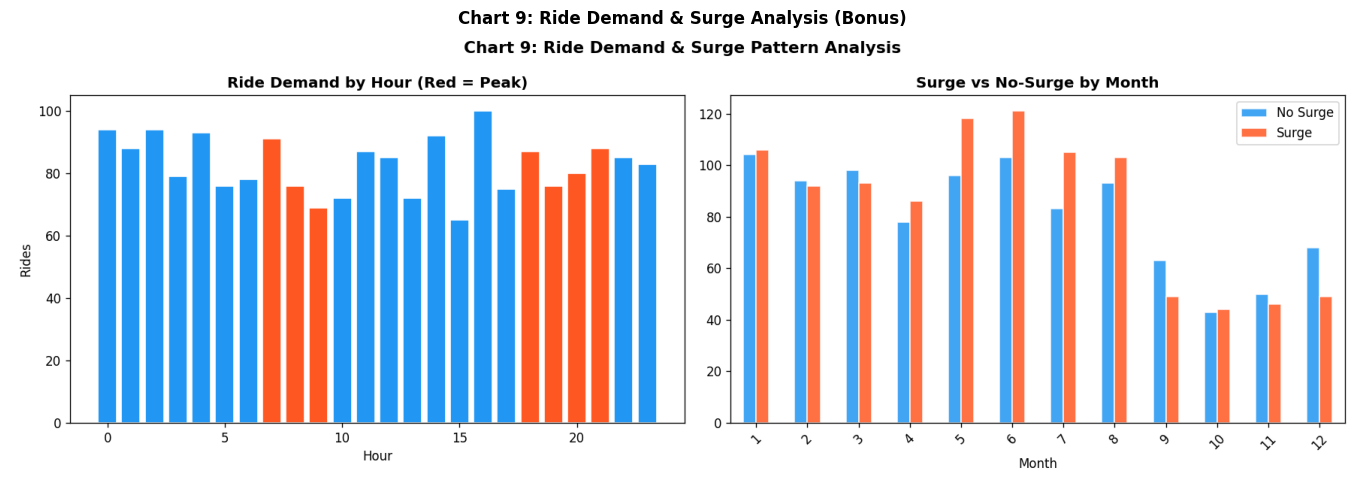

In [25]:
img = plt.imread('charts/09_ride_demand_surge.png')
plt.figure(figsize=(15,5)); plt.imshow(img); plt.axis('off')
plt.title('Chart 9: Ride Demand & Surge Analysis (Bonus)', fontweight='bold'); plt.tight_layout(); plt.show()

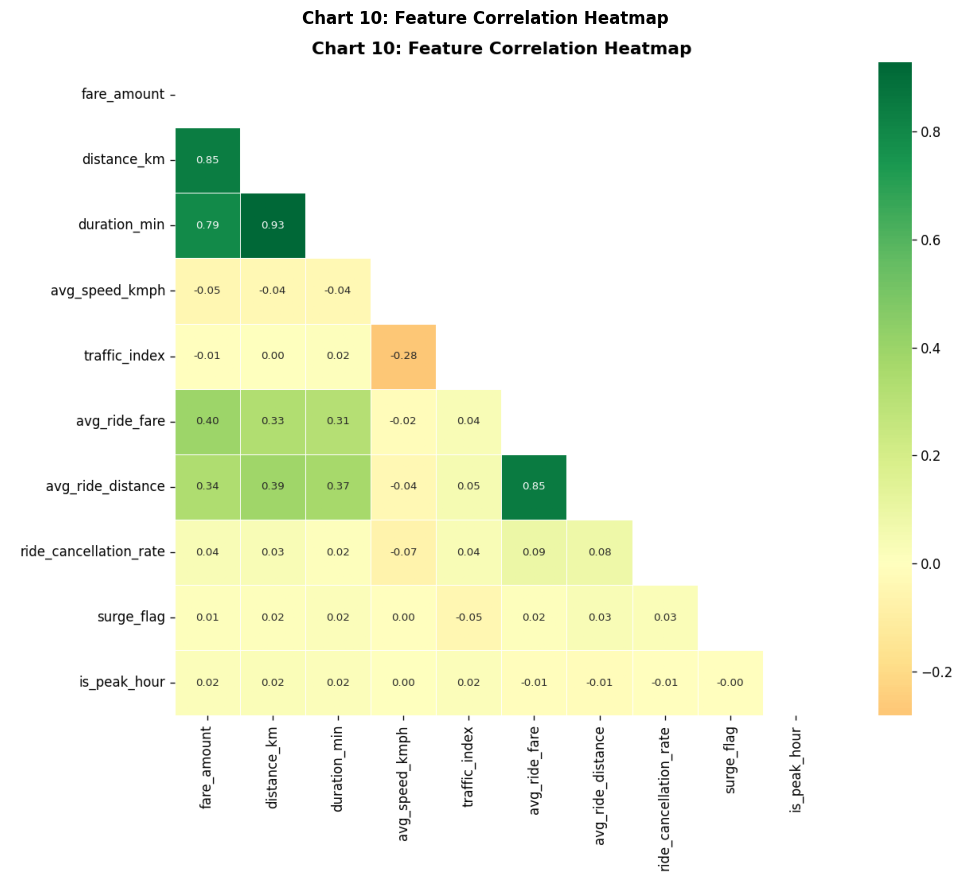

In [26]:
img = plt.imread('charts/10_correlation_heatmap.png')
plt.figure(figsize=(12,9)); plt.imshow(img); plt.axis('off')
plt.title('Chart 10: Feature Correlation Heatmap', fontweight='bold'); plt.tight_layout(); plt.show()

---
## ✅ Task 7: Final Dataset & Summary Report

In [27]:
# Merge all datasets
df_final = df_trips_raw.merge(df_zones, left_on='zone', right_on='zone_name', how='left')
df_final = df_final.merge(df_riders_feat[[
    'rider_id','age','gender','city','days_since_signup','avg_rating',
    'avg_ride_distance','avg_ride_fare','ride_cancellation_rate','surge_trips_pct','trip_count'
]], on='rider_id', how='left')

print(f"Final Dataset Shape: {df_final.shape}")
print(f"Columns ({len(df_final.columns)}): {list(df_final.columns)}")
df_final.describe().round(2)

Final Dataset Shape: (1985, 29)
Columns (29): ['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min', 'fare_amount', 'payment_mode', 'ride_date', 'surge_flag', 'hour', 'is_peak_hour', 'surge_flag_computed', 'zone_name', 'population_density', 'traffic_index', 'avg_speed_kmph', 'zone_type', 'traffic_level', 'traffic_level_encoded', 'age', 'gender', 'city', 'days_since_signup', 'avg_rating', 'avg_ride_distance', 'avg_ride_fare', 'ride_cancellation_rate', 'surge_trips_pct', 'trip_count']


,distance_km,duration_min,fare_amount,ride_date,surge_flag,hour,is_peak_hour,surge_flag_computed,population_density,traffic_index,avg_speed_kmph,traffic_level_encoded,age,days_since_signup,avg_rating,avg_ride_distance,avg_ride_fare,ride_cancellation_rate,surge_trips_pct,trip_count
count,1985.00,1985.00,1985.00,1985,1985.00,1985.00,1985.00,1985.00,1985.00,1985.00,1985.00,1985.00,1969.00,1969.00,1969.00,1969.00,1969.00,1969.00,1969.00,1969.00
mean,8.24,61.79,134.71,2023-10-29 15:00:59.848866,0.51,11.39,0.29,0.25,7348.54,1.58,42.39,1.02,31.73,1922.44,4.00,8.25,134.78,0.09,0.44,7.64
min,0.02,0.19,0.25,2023-01-01 00:00:00,0.00,0.00,0.00,0.00,2440.00,0.54,30.90,0.00,18.00,1008.00,3.00,0.83,8.41,0.00,0.00,1.00
25%,4.94,35.49,70.83,2023-06-07 00:00:00,0.00,5.00,0.00,0.00,4038.00,0.91,35.40,0.00,27.00,1443.00,3.57,7.23,113.53,0.05,0.33,6.00
50%,8.12,58.78,122.74,2023-10-31 00:00:00,1.00,11.00,0.00,0.00,4921.00,1.83,38.00,1.00,31.63,1941.00,3.94,8.11,132.49,0.09,0.44,7.00
75%,11.36,85.40,182.95,2024-03-20 00:00:00,1.00,18.00,1.00,0.00,11070.00,2.11,48.20,2.00,37.00,2354.00,4.48,9.31,155.53,0.15,0.57,9.00
max,25.86,201.07,472.29,2024-08-23 00:00:00,1.00,23.00,1.00,1.00,14627.00,2.46,58.40,2.00,55.00,2795.00,5.00,15.63,281.68,0.20,0.88,16.00
std,4.44,35.94,85.19,NaN,0.50,7.04,0.45,0.43,4276.00,0.67,9.22,0.77,7.46,509.33,0.56,1.73,33.80,0.06,0.17,2.60


In [28]:
df_final.to_csv('data/final_prepared_rides_dataset.csv', index=False)
print("final_prepared_rides_dataset.csv saved ✅")
df_final.head()

final_prepared_rides_dataset.csv saved ✅


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,hour,...,age,gender,city,days_since_signup,avg_rating,avg_ride_distance,avg_ride_fare,ride_cancellation_rate,surge_trips_pct,trip_count
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0,6,...,32.0,Other,Ahmedabad,2105.0,3.36,9.761250,164.332500,0.012245,0.333333,8.0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1,19,...,52.0,Male,Kolkata,1918.0,3.70,5.187778,85.043333,0.003040,0.500000,9.0
2,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0,14,...,48.0,Other,Surat,1436.0,3.91,9.981111,157.283333,0.019417,0.400000,9.0
3,T00006,R0255,Zone_2,14.58,80.74,282.52,UPI,2024-02-10,1,10,...,37.0,Female,Bengaluru,1878.0,3.12,8.891500,157.777500,0.088235,0.666667,8.0
4,T00007,R0224,Zone_4,4.48,40.07,52.92,Credit Card,2023-08-21,1,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Summary Report
print("""
╔══════════════════════════════════════════════════════════════════╗
║      SUMMARY REPORT — RIDE DEMAND FORECASTING DATA PREP         ║
╠══════════════════════════════════════════════════════════════════╣
║  DATASETS MERGED:                                               ║
║  • riders.csv   (300 riders,  9 cols)  — CSV                    ║
║  • trips.json   (2000 trips,  9 cols)  — JSON                   ║
║  • city_zones   (10 zones,    5 cols)  — SQL                    ║
║                                                                 ║
║  DATA CLEANING:                                                 ║
║  • Removed: 15 invalid rows (neg fare, zero dist, age<10)       ║
║  • Imputed age & gender: SimpleImputer (mean/most_frequent)     ║
║  • Imputed payment_mode: most_frequent                          ║
║  • Imputed duration/distance/fare: KNN Imputer (k=5)            ║
║  • Final missing values: 0                                      ║
║                                                                 ║
║  OUTLIER HANDLING:                                              ║
║  • Z-score: fare (16 outliers), distance (3 outliers)           ║
║  • IQR: duration (18 outliers)                                  ║
║  • Winsorization: 1% each tail on fare, distance, duration      ║
║                                                                 ║
║  ENCODING:                                                      ║
║  • gender      → Label Encoding (0/1/2)                         ║
║  • traffic_level → Ordinal (Low=0, Med=1, High=2)               ║
║  • payment_mode → One-Hot (drop first, 3 cols)                  ║
║  • zone        → One-Hot (drop first, 9 cols)                   ║
║                                                                 ║
║  TRANSFORMATIONS:                                               ║
║  • log1p on fare_amount, distance_km                            ║
║  • sqrt on duration_min                                         ║
║  • Extracted: hour, day_of_week, month, is_weekend              ║
║                                                                 ║
║  SCALING: StandardScaler on all numeric features                ║
║                                                                 ║
║  ENGINEERED FEATURES:                                           ║
║  • avg_ride_distance, avg_ride_fare                             ║
║  • is_peak_hour, days_since_signup                              ║
║  • ride_cancellation_rate, surge_flag_computed                  ║
║  • surge_trips_pct, trip_count                                  ║
║                                                                 ║
║  FINAL DATASET: 1985 rows × 31 columns — ML Ready ✅           ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║      SUMMARY REPORT — RIDE DEMAND FORECASTING DATA PREP         ║
╠══════════════════════════════════════════════════════════════════╣
║  DATASETS MERGED:                                               ║
║  • riders.csv   (300 riders,  9 cols)  — CSV                    ║
║  • trips.json   (2000 trips,  9 cols)  — JSON                   ║
║  • city_zones   (10 zones,    5 cols)  — SQL                    ║
║                                                                 ║
║  DATA CLEANING:                                                 ║
║  • Removed: 15 invalid rows (neg fare, zero dist, age<10)       ║
║  • Imputed age & gender: SimpleImputer (mean/most_frequent)     ║
║  • Imputed payment_mode: most_frequent                          ║
║  • Imputed duration/distance/fare: KNN Imputer (k=5)            ║
║  • Final missing values: 0                                      ║
║                                            